#### Mélodie ROSSI - L2 SPRINT-B

# Le réchauffement climatique

![image](./AnoTempe.png)

Crédits : NOAA - NASA - UKMet / Traitement ONERC

On va tenter de répondre dans ce projet à une question : $\textbf{des mesures de température mesurées localement au cours du dernier siècle mettent-elles en évidence un réchauffement significatif ?}$ On va travailler pour répondre à cette question sur les relevés de température enregistrés quotidiennement depuis juin 1920 à [la station météorologique de Montélimar](https://donneespubliques.meteofrance.fr/metadonnees_publiques/fiches/fiche_26198001.pdf). Elles peuvent être téléchargées librement depuis le [site de l'ECAD](https://www.ecad.eu/) (European Climate Assessment & Dataset).

Vous trouverez dans le fichier *montelimar_temperature.dat* un fichier de données préparées avec :
- colonne 1 : date en MJD (*modified Julian Day*)
- colonne 2 : température en degrés Celsius

La première problématique à laquelle vous êtes confrontés est de faire apparaître un effet faible et lent (on voit dans la figure ci-dessus que le réchauffement est de l'ordre de 1 °C sur les 30 dernières dernières années) à l'échelle des données (amplitudes de fluctuations quotidiennes ou saisonnières dix fois supérieures typiquement).

La seconde problématique est de montrer que l'effet observé est significatif, c'est-à-dire que cette augmentation des températures ne correspond pas à une fluctuation statistique. Pour cela on supposera que l'erreur sur les mesures de température est de l'ordre de 5 °C. C'est l'ordre de grandeur des fluctuations quotidiennes qui ne seront pas prises en compte dans un modèle qui décrit des variations saisonnières.

Les variations saisonnières de la température peuvent être modélisée par une sinusoïde de période une année. Il faut utiliser un modèle du type sinusoïdal :

$$ T(t) = A \sin{(\omega t + \phi)} + B $$

où les paramètres $A$ (amplitude), $\phi$ (phase) et $B$ (température moyenne) doivent être ajustés aux données, alors que $\omega = 2\pi/1\text{ an}$. Cependant, un tel modèle ajusté sur l'ensemble des données ne donnera aucune augmentation moyenne de la température. On pourra par exemple essayer d'appliquer un ajustement sinusoïdal pour chaque décennie, et voir si le paramètre $B$ (température moyenne) augmente. On peut aussi affiner ce modèle en se disant que l'accroissement lent de la température est linéaire. On pourra alors utiliser un modèle de type :

$$ T(t) = A \sin{(\omega t + \phi)} + B + C t $$

où $C$ est un nouveau paramètre à ajuster, qui correspond à l'accroissement linéaire lent de la température.

On gardera aussi en tête que l'ajustement par la fonction `curve_fit` permet de calculer assez facilement l'incertitude sur les paramètres de l'ajustement. Cela permettra de statuer sur le caractère significatif du réchauffement. On veillera alors à discuter les erreurs estimées sur les paramètres ajustés.

___

# Des mesures de température mesurées localement au cours du dernier siècle mettent-elles en évidence un réchauffement significatif ?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timedelta

from scipy.optimize import curve_fit

## Lire le fichier .dat avec Pandas

La première chose à faire est d'ouvrir le fichier *montelimar_temperature.dat*. Pour cela, on utilise la fonction *pd.read_csv()* de Pandas pour importer des données mixtes, c'est-à-dire des dates et des floats.

In [2]:
df = pd.read_csv('montelimar_temperature.dat', sep="\s+", names=['MJD','DEGREES'])
df

,MJD,DEGREES
0,22553,22.6
1,22554,22.6
2,22555,24.8
3,22556,17.5
4,22557,16.5
...,...,...
36290,58844,9.3
36291,58845,10.1
36292,58846,6.4
36293,58847,4.4


### Convertir les dates MJD (Modified Julian Date) en Day/Month/Year

In [3]:
from astropy.time import Time 

In [4]:
# Convertir en JD (Julian Date)
df['JD'] = df['MJD'] + 2_400_000.5

# Convertir en objet astropy Time
t = Time(df['JD'], format='jd')

# Convertir en UTC
df['UTC'] = t.to_datetime()
df['UTC']

/opt/tljh/user/lib/python3.9/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 14379 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


0       1920-08-17
1       1920-08-18
2       1920-08-19
3       1920-08-20
4       1920-08-21
           ...    
36290   2019-12-27
36291   2019-12-28
36292   2019-12-29
36293   2019-12-30
36294   2019-12-31
Name: UTC, Length: 36295, dtype: datetime64[ns]

On enlève les colonnes MJD et JD.

In [5]:
df = df.drop(columns = 'MJD')
df = df.drop(columns = 'JD')

In [6]:
df

,DEGREES,UTC
0,22.6,1920-08-17
1,22.6,1920-08-18
2,24.8,1920-08-19
3,17.5,1920-08-20
4,16.5,1920-08-21
...,...,...
36290,9.3,2019-12-27
36291,10.1,2019-12-28
36292,6.4,2019-12-29
36293,4.4,2019-12-30


In [7]:
df['Year'], df['Month'], df['Day']= df['UTC'].dt.year, df['UTC'].dt.month, df['UTC'].dt.day
df

,DEGREES,UTC,Year,Month,Day
0,22.6,1920-08-17,1920,8,17
1,22.6,1920-08-18,1920,8,18
2,24.8,1920-08-19,1920,8,19
3,17.5,1920-08-20,1920,8,20
4,16.5,1920-08-21,1920,8,21
...,...,...,...,...,...
36290,9.3,2019-12-27,2019,12,27
36291,10.1,2019-12-28,2019,12,28
36292,6.4,2019-12-29,2019,12,29
36293,4.4,2019-12-30,2019,12,30


### Organisation en décennies

In [8]:
decade = []
i=0

while i < len(df):
    if df['Year'][i] < 1930 :
        decade.append(int(1920))
    elif df['Year'][i] < 1940 and df['Year'][i] >= 1930 :
        decade.append(int(1930))
    elif df['Year'][i] < 1950 and df['Year'][i] >= 1940 :
        decade.append(int(1940))
    elif df['Year'][i] < 1960 and df['Year'][i] >= 1950 :
        decade.append(int(1950))
    elif df['Year'][i] < 1970 and df['Year'][i] >= 1960 :
        decade.append(int(1960))
    elif df['Year'][i] < 1980 and df['Year'][i] >= 1970 :
        decade.append(int(1970))
    elif df['Year'][i] < 1990 and df['Year'][i] >= 1980 :
        decade.append(int(1980))
    elif df['Year'][i] < 2000 and df['Year'][i] >= 1990 :
        decade.append(int(1990))
    elif df['Year'][i] < 2010 and df['Year'][i] >= 2000 :
        decade.append(int(2000))
    elif df['Year'][i] < 2020 and df['Year'][i] >= 2010:
        decade.append(int(2010))
    i+=1

In [9]:
df['Decade'] = pd.Series(decade)
df

,DEGREES,UTC,Year,Month,Day,Decade
0,22.6,1920-08-17,1920,8,17,1920
1,22.6,1920-08-18,1920,8,18,1920
2,24.8,1920-08-19,1920,8,19,1920
3,17.5,1920-08-20,1920,8,20,1920
4,16.5,1920-08-21,1920,8,21,1920
...,...,...,...,...,...,...
36290,9.3,2019-12-27,2019,12,27,2010
36291,10.1,2019-12-28,2019,12,28,2010
36292,6.4,2019-12-29,2019,12,29,2010
36293,4.4,2019-12-30,2019,12,30,2010


## Tracé des graphes par décennie

In [10]:
Decade1920 = df[df['Decade'] == 1920]
Decade1930 = df[df['Decade'] == 1930]
Decade1940 = df[df['Decade'] == 1940]
Decade1950 = df[df['Decade'] == 1950]
Decade1960 = df[df['Decade'] == 1960]
Decade1970 = df[df['Decade'] == 1970]
Decade1980 = df[df['Decade'] == 1980]
Decade1990 = df[df['Decade'] == 1990]
Decade2000 = df[df['Decade'] == 2000]
Decade2010 = df[df['Decade'] == 2010]

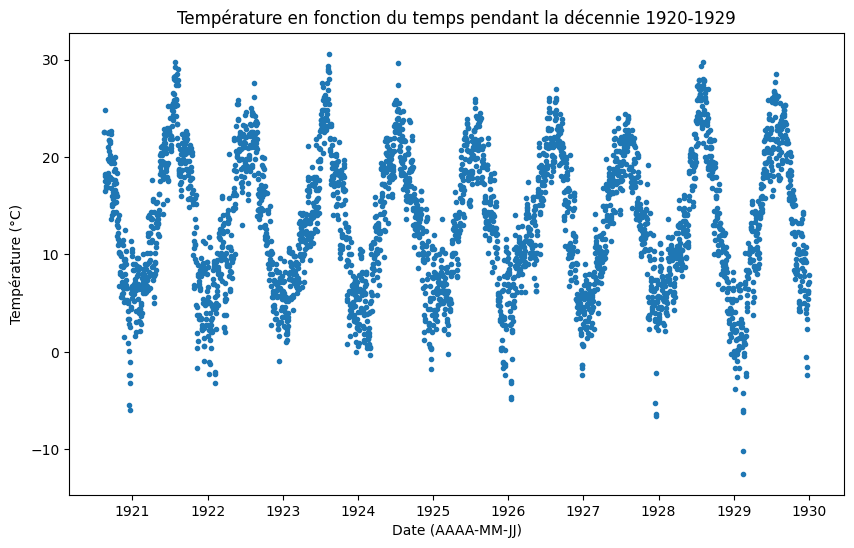

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(Decade1920['UTC'], Decade1920['DEGREES'], marker='.')
plt.xlabel('Date (AAAA-MM-JJ)')
plt.ylabel('Température (°C)')
plt.title('Température en fonction du temps pendant la décennie 1920-1929')

plt.show()

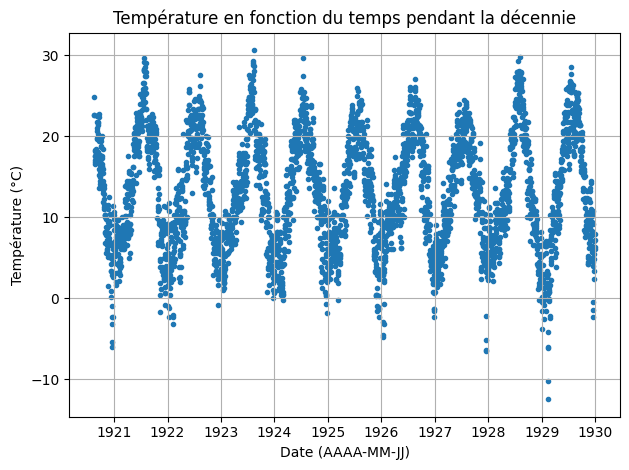

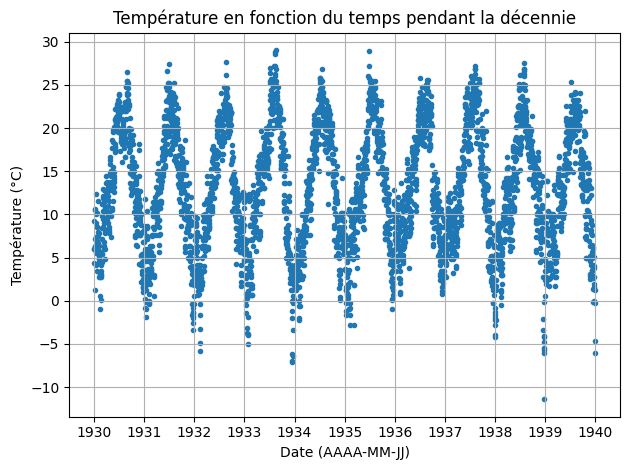

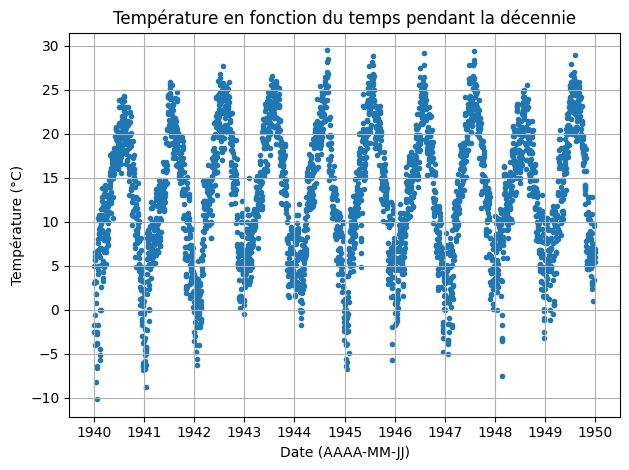

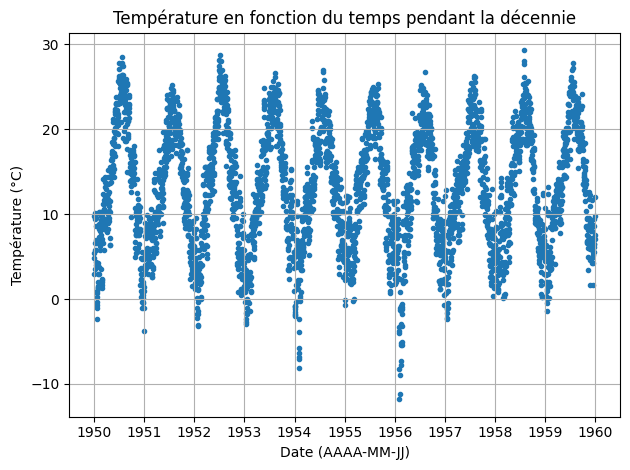

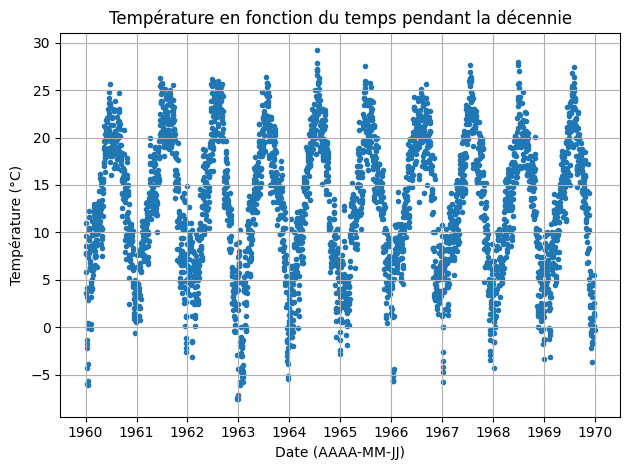

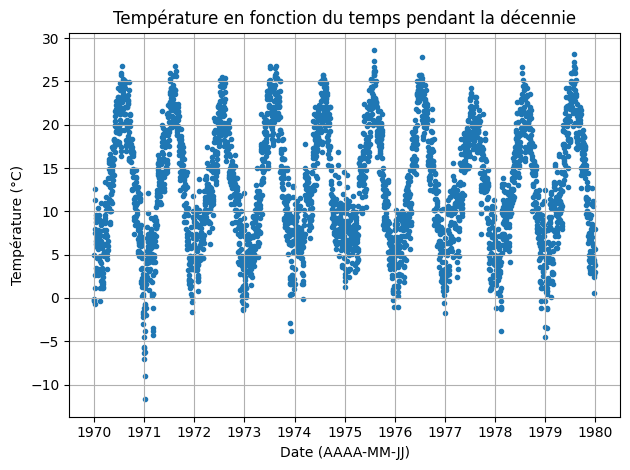

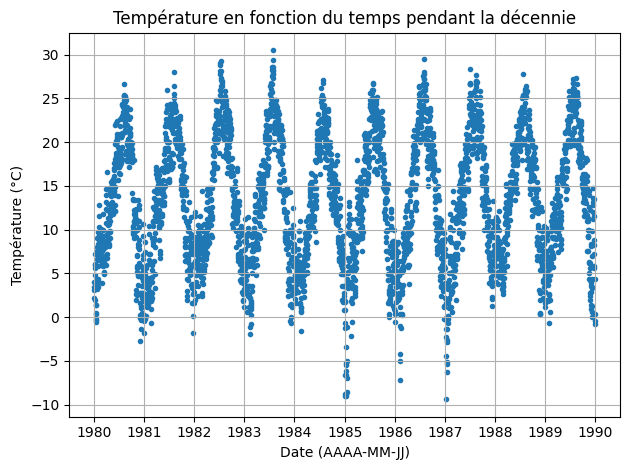

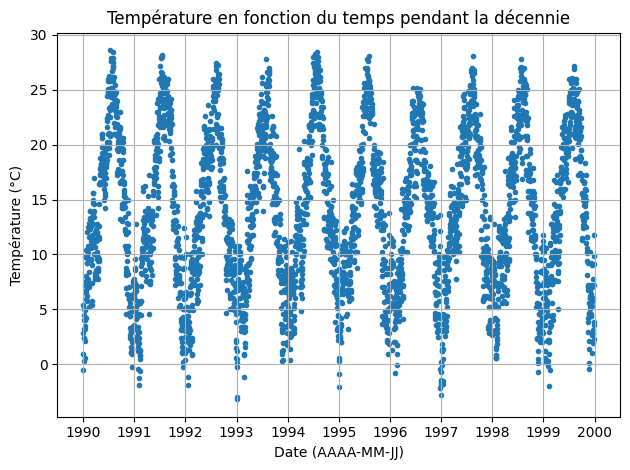

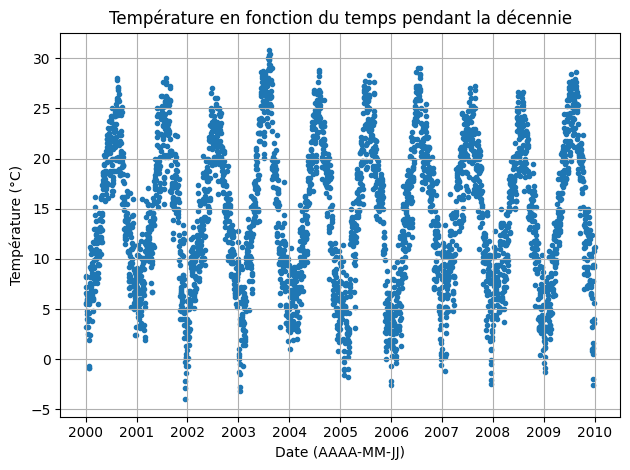

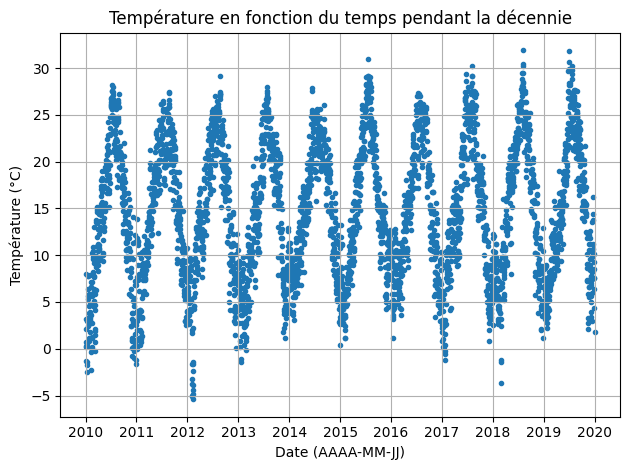

In [12]:
lst_decade = [Decade1920, Decade1930, Decade1940, Decade1950, Decade1960, Decade1970, Decade1980, Decade1990, Decade2000, Decade2010]

for l in lst_decade:
    #subplots
    plt.title('Température en fonction du temps pendant la décennie')
    plt.scatter(l['UTC'], l['DEGREES'], marker='.')
    plt.xlabel('Date (AAAA-MM-JJ)')
    plt.ylabel('Température (°C)')
    plt.grid()
    plt.tight_layout()
    plt.show()

## Modèle saisonnier
$$ T(t) = A \sin{(\omega t + \phi)} + B $$

In [13]:
import datetime
from dateutil.relativedelta import relativedelta

In [14]:
df

,DEGREES,UTC,Year,Month,Day,Decade
0,22.6,1920-08-17,1920,8,17,1920
1,22.6,1920-08-18,1920,8,18,1920
2,24.8,1920-08-19,1920,8,19,1920
3,17.5,1920-08-20,1920,8,20,1920
4,16.5,1920-08-21,1920,8,21,1920
...,...,...,...,...,...,...
36290,9.3,2019-12-27,2019,12,27,2010
36291,10.1,2019-12-28,2019,12,28,2010
36292,6.4,2019-12-29,2019,12,29,2010
36293,4.4,2019-12-30,2019,12,30,2010


In [15]:
d_start = datetime.date(1920, 8, 17)
d_end = datetime.date(2019, 12, 31)
print(d_end-d_start)

36295 days, 0:00:00


Les index indiquent le nombre de jours écoulés depuis le 17 août 1920.

In [16]:
df.index

RangeIndex(start=0, stop=36295, step=1)

In [17]:
decade_1920 = df[df.index < 3287]
decade_1920

,DEGREES,UTC,Year,Month,Day,Decade
0,22.6,1920-08-17,1920,8,17,1920
1,22.6,1920-08-18,1920,8,18,1920
2,24.8,1920-08-19,1920,8,19,1920
3,17.5,1920-08-20,1920,8,20,1920
4,16.5,1920-08-21,1920,8,21,1920
...,...,...,...,...,...,...
3282,23.4,1929-08-12,1929,8,12,1920
3283,22.4,1929-08-13,1929,8,13,1920
3284,25.5,1929-08-14,1929,8,14,1920
3285,23.5,1929-08-15,1929,8,15,1920


In [18]:
df['omega'] = 2*np.pi*np.ones(len(df)) # convertir en années^-1
df['omega']

0        6.283185
1        6.283185
2        6.283185
3        6.283185
4        6.283185
           ...   
36290    6.283185
36291    6.283185
36292    6.283185
36293    6.283185
36294    6.283185
Name: omega, Length: 36295, dtype: float64

In [21]:
def mod_sinusoidal_B(t, A, B, phi) :
    """T(t) = A * np.sin(omega*t + phi) + B"""
    return A * np.sin(df['omega']*t + phi) + B

In [36]:
# Ajustement du modèle
ts = np.array([t for t in df.index])
parameters, covariance = curve_fit(mod_sinusoidal_B, ts, df['DEGREES'])

plt.scatter(Index1920['UTC'], Index1920['DEGREES'], marker='.')
plt.plot(ts, mod_sinusoidal_B(ts, *parameters))
plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
# Identification des paramètres du modèle
a, b = solution[0]
v0 = a
g = -b

# Affichage du résultat
print('v0 = {:4.2f} m.s**-1'.format(v0))
print('g = {:4.2f} m.s**-2'.format(g))

# Calcul du modèle
t_mod = np.linspace(0, 1, N)
v_mod = modlin(t_mod, a, b)

# Calcul de la somme S
Si = (v_exp - v_mod) ** 2
S = np.sum(Si)

# Représentation graphique du modèle et des données
plt.plot(t_exp, v_exp, '+k', label = 'données expérimentales')
plt.plot(t_mod, v_mod, '-b', label = 'modèle')
plt.title('S = ' + str(S))
plt.xlabel('t [s]')
plt.ylabel('v [m/s]')
plt.grid()
plt.legend()
plt.show()